In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.io as pio
import numpy as np

from colors import PALETTES
pio.templates.default = "ggplot2"

In [2]:
df_data = pd.read_csv("all_non_knowledge_results/data_mixture_results.csv", sep=";")
main_paper_versions = [10, 12, 14, 3, 2, 1, 4, 8]

df_data_paper = df_data[df_data["version"].isin(main_paper_versions)].copy()
new_version_index = {10:1, 12:2, 14:3, 3:4, 2:5, 1:6, 4:7, 8:8}

df_data_paper["final_version"] = df_data_paper["version"].replace(new_version_index)

stats = df_data_paper.groupby('final_version').agg({
            'F1_synthetic': ['mean', 'std', 'min', 'max'],
            'F1_ground_truth': ['mean', 'std', 'min', 'max'],
            'F1_OOD': ['mean', 'std', 'min', 'max']
        }).reset_index()

df_data_paper.head()

,version,base_model,F1_synthetic,F1_ground_truth,F1_OOD,final_version
0,1.0,roberta-base,0.95,0.93,0.81,6.0
1,1.0,roberta-large,0.97,0.96,0.73,6.0
2,1.0,modernbert-base,0.91,0.98,0.62,6.0
3,2.0,roberta-base,0.89,0.87,0.59,5.0
4,2.0,roberta-large,0.87,0.93,0.49,5.0


In [3]:
df_data[df_data["version"].isin([4, 7, 8])]

,version,base_model,F1_synthetic,F1_ground_truth,F1_OOD
9,4.0,roberta-base,0.97,0.94,0.79
10,4.0,roberta-large,0.96,0.95,0.68
11,4.0,modernbert-base,0.94,0.93,0.71
18,7.0,roberta-base,0.84,0.91,0.77
19,7.0,roberta-large,0.81,0.89,0.69
20,7.0,modernbert-base,0.78,0.86,0.73
21,8.0,roberta-base,0.99,0.94,0.73
22,8.0,roberta-large,0.99,0.96,0.81
23,8.0,modernbert-base,0.94,0.94,0.60


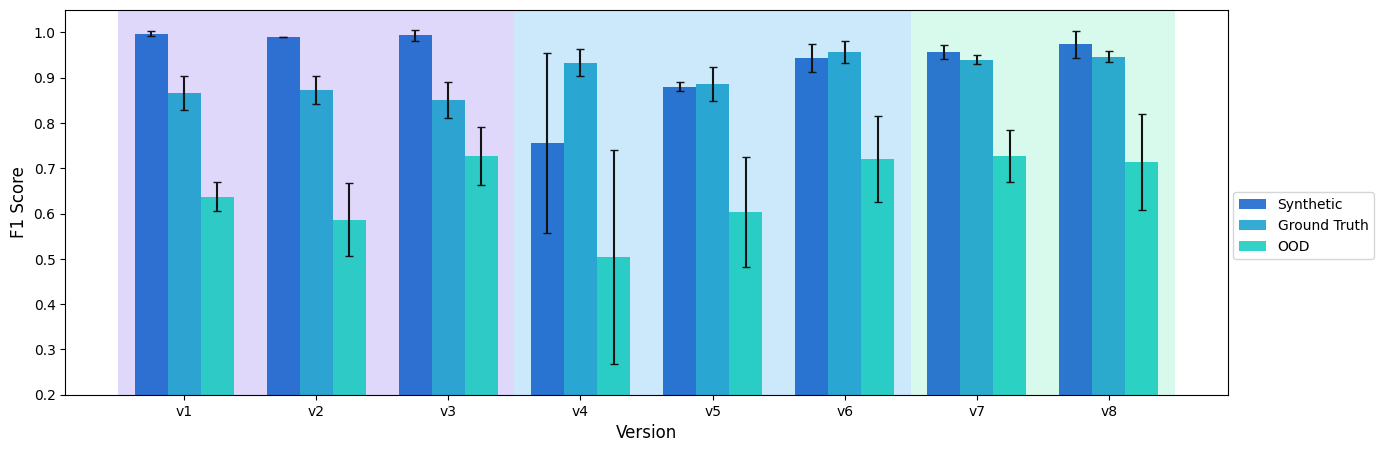

In [35]:
fig, ax = plt.subplots(figsize=(15, 5))

main_paper_versions = [1, 2, 3, 4, 5, 6, 7, 8] #, 9, 10, 11, 12, 13, 14]

x = np.arange(len(main_paper_versions))
width = 0.25

version_to_x = {v: i for i, v in enumerate(main_paper_versions)}

for v, x_pos in version_to_x.items():
    x_space_left = 0.5
    x_space_right = 0.5
    if 1 <= v <= 3:
        color = '#603CE6'  # Light yellow
        #x_space_left = 1.5
    elif 4 <= v <= 6:
        color = '#008FEC'  # Light orange/peach
    elif 7 <= v <= 8:
        color = '#3CE6A2'  # Light green
        #x_space_right = 1.5
    else:
        continue
    
    # Add background rectangle spanning the full height
    ax.axvspan(x_pos - x_space_left, x_pos + x_space_right, alpha=0.2, facecolor=color, zorder=0, linestyle=None)

color_palette = PALETTES["blue_green"]

synthetic_means = stats['F1_synthetic']['mean'].values
synthetic_stds = stats['F1_synthetic']['std'].values
gt_means = stats['F1_ground_truth']['mean'].values
gt_stds = stats['F1_ground_truth']['std'].values
ood_means = stats['F1_OOD']['mean'].values
ood_stds = stats['F1_OOD']['std'].values

bars1 = ax.bar(x - width, synthetic_means, width, label='Synthetic', 
               color=color_palette["synthetic"], alpha=0.8, yerr=synthetic_stds, ecolor= "#141414",capsize=3)
bars2 = ax.bar(x, gt_means, width, label='Ground Truth', 
               color=color_palette["GT"], alpha=0.8, yerr=gt_stds, ecolor= "#141414", capsize=3)
bars3 = ax.bar(x + width, ood_means, width, label='OOD', 
               color=color_palette["OOD"], alpha=0.8, yerr=ood_stds, ecolor= "#141414", capsize=3)

ax.set_xlabel('Version', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
#ax.set_title('Model Performance Across Key Experimental Versions\n(Mean ± Std across 3 architectures)', 
#             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'v{v}' for v in main_paper_versions])
#ax.legend(loc='best', fontsize=11, framealpha=0.9)
#ax.grid(axis='y', alpha=0.5, linestyle='--')
#ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_ylim([0.2, 1.05])
#plt.xlim([0,x])
#plt.tight_layout()
fig.legend(loc='outside right')
plt.savefig("all_non_knowledge_results/F1-scores-per-dataset-version.pdf")
plt.show()

ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of labels (3).

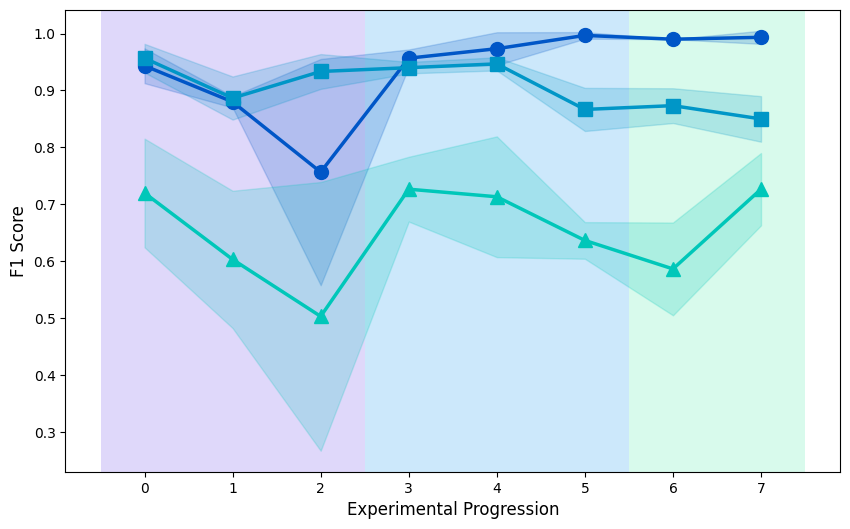

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

version_to_x = {v: i for i, v in enumerate(main_paper_versions)}

for v, x_pos in version_to_x.items():
    if 1 <= v <= 3:
        color = '#603CE6'  # Light yellow
    elif 4 <= v <= 6:
        color = '#008FEC'  # Light orange/peach
    elif 7 <= v <= 8:
        color = '#3CE6A2'  # Light green
    else:
        continue
    
    # Add background rectangle spanning the full height
    ax.axvspan(x_pos - 0.5, x_pos + 0.5, alpha=0.2, facecolor=color, zorder=0, linestyle=None)

x_pos = np.arange(len(main_paper_versions))

narrative_stats = df_data_paper.groupby('version').agg({
    'F1_synthetic': ['mean', 'std'],
    'F1_ground_truth': ['mean', 'std'],
    'F1_OOD': ['mean', 'std']
}).reset_index()

color_palette = PALETTES["blue_green"]

# Plot with error bands
syn_means = narrative_stats['F1_synthetic']['mean'].values
syn_stds = narrative_stats['F1_synthetic']['std'].values
gt_means = narrative_stats['F1_ground_truth']['mean'].values
gt_stds = narrative_stats['F1_ground_truth']['std'].values
ood_means = narrative_stats['F1_OOD']['mean'].values
ood_stds = narrative_stats['F1_OOD']['std'].values

ax.plot(x_pos, syn_means, 'o-', label='Synthetic', color=color_palette["synthetic"], 
        linewidth=2.5, markersize=10)
ax.fill_between(x_pos, syn_means - syn_stds, syn_means + syn_stds, 
                alpha=0.2, color=color_palette["synthetic"])

ax.plot(x_pos, gt_means, 's-', label='Ground Truth', color=color_palette["GT"], 
        linewidth=2.5, markersize=10)
ax.fill_between(x_pos, gt_means - gt_stds, gt_means + gt_stds, 
                alpha=0.2, color=color_palette["GT"])

ax.plot(x_pos, ood_means, '^-', label='OOD', color=color_palette["OOD"], 
        linewidth=2.5, markersize=10)
ax.fill_between(x_pos, ood_means - ood_stds, ood_means + ood_stds, 
                alpha=0.2, color=color_palette["OOD"])

ax.set_xlabel('Experimental Progression', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
# ax.set_title('Impact of Data Modifications on Model Performance\n(Shaded regions show ± 1 Std)', 
#              fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
# Customize these labels based on your actual experiments
ax.set_xticklabels(['v10:\nBaseline', 'v12:\n+Modification', 'v14:\nFinal'],
                   fontsize=11)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim([0.45, 1.05])

plt.tight_layout()
plt.show()